In [3]:
import torch


# def rbf_kernel(X1, X2, lengthscale=1.0, variance=1.0):
#     """
#     Computes the RBF kernel matrix between two sets of points.
#     """
#     lengthscale = torch.as_tensor(lengthscale, dtype=X1.dtype, device=X1.device)
#     variance = torch.as_tensor(variance, dtype=X1.dtype, device=X1.device)
#     sqdist = torch.cdist(X1, X2, p=2).pow(2)
#     return variance * torch.exp(-0.5 * sqdist / lengthscale**2)

def rbf_kernel(X1, X2, lengthscale, variance=1.0):
    """
    Computes the RBF kernel matrix with ARD support.

    Args:
        X1 (torch.Tensor): A tensor of size (N, D).
        X2 (torch.Tensor): A tensor of size (M, D).
        lengthscale (torch.Tensor): A tensor of size (D,) representing the lengthscale for each dimension.
        variance (float): The kernel variance.
    """
    # Ensure variance is a tensor on the correct device
    variance = torch.as_tensor(variance, dtype=X1.dtype, device=X1.device)
    
    # Scale each dimension of X1 and X2 by the corresponding lengthscale
    # This uses broadcasting to efficiently perform the operation
    X1_scaled = X1 / lengthscale
    X2_scaled = X2 / lengthscale
    
    # Compute the squared Euclidean distance in the scaled space
    sqdist = torch.cdist(X1_scaled, X2_scaled, p=2).pow(2)
    
    return variance * torch.exp(-0.5 * sqdist)

# --- Helper class for Priors ---
class GammaPrior:
    def __init__(self, concentration, rate):
        self.concentration = concentration
        self.rate = rate

    def log_prob(self, x):
        # Log probability density of Gamma distribution (constants omitted)
        return (self.concentration - 1.0) * torch.log(x.clamp(min=1e-9)) - self.rate * x

class LogNormalPrior:
    def __init__(self, loc, scale):
        self.loc = loc
        self.scale = scale
        self.var = scale**2

    def log_prob(self, x):
        # Log probability density of LogNormal distribution (constants omitted)
        log_x = torch.log(x.clamp(min=1e-9))
        return -log_x - (log_x - self.loc)**2 / (2 * self.var)

/tmp/ipykernel_2735962/171885314.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))


Starting optimization with mode_optimizer='lbfgs' and hyper_optimizer='adam'...


  0%|          | 0/90 [00:00<?, ?it/s]

Loss (Neg. Log Post.): 138.9639: 100%|██████████| 90/90 [00:30<00:00,  2.94it/s]


Optimization finished.

--- Learned Hyperparameters ---
Kernel Lengthscale: 0.358
Kernel Variance: 0.626
Likelihood Sigma: 0.424
Prior DoF (nu_f): 0.692
Likelihood DoF (nu_e): 5.768


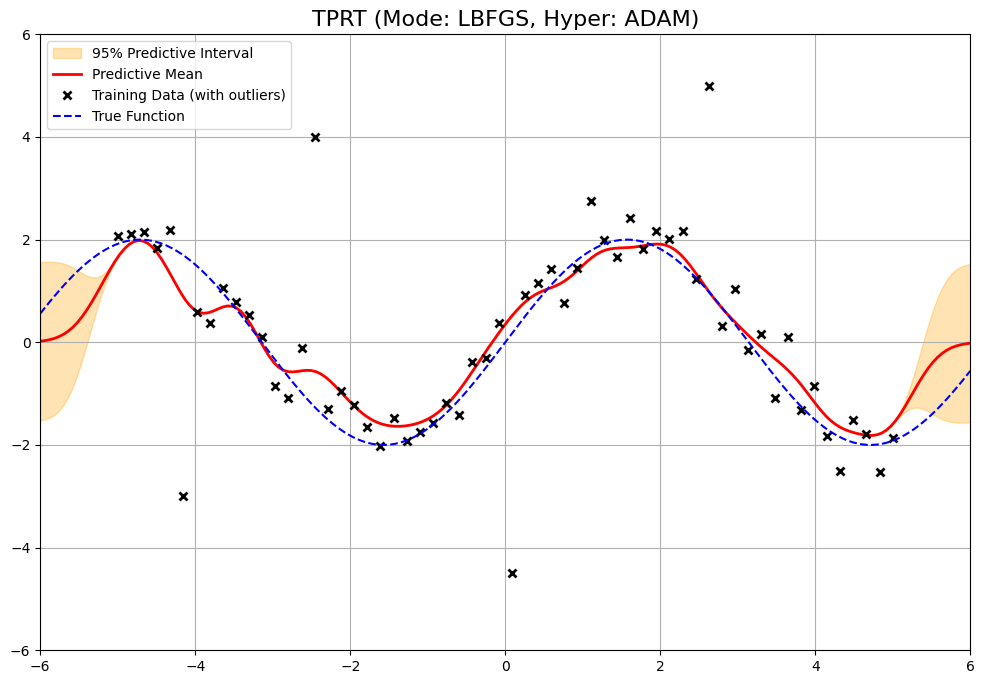

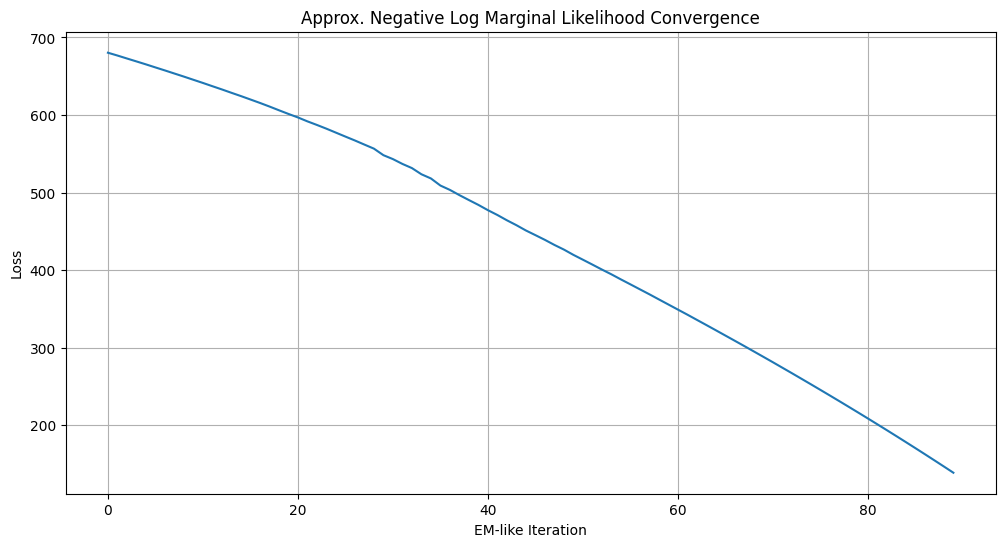

In [5]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from scipy.stats import norm
import tqdm
import logging
import numpy as np


# Set default tensor type for better performance with matrix operations
torch.set_default_dtype(torch.float64)


class TPRTFullBatch_Tang:
    """
    Implementation of the full (non-sparse) Student-t Process regression model
    using the Laplace Approximation, based on Tang et al. (2017).
    This version includes priors on all hyperparameters for MAP estimation.
    """
    def __init__(self, X, y, nu_f=2.1, nu_e=2.1,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=1.0,
                 mode_optimizer='lbfgs', hyper_optimizer='adam'):
        self.X = X
        self.y = y.view(-1, 1)
        self.N, self.D = X.shape

        # ★ 変更点: ARDとIsotropicの自動対応ロジック
        dtype = self.X.dtype
        if kernel_lengthscale is None:
            # デフォルトは全ての次元で1.0
            kernel_lengthscale = torch.ones(self.D, dtype=dtype)
        else:
            kernel_lengthscale = torch.as_tensor(kernel_lengthscale, dtype=dtype)
        
        # スカラーが渡された場合、次元Dのベクトルに拡張
        if kernel_lengthscale.ndim == 0:
            kernel_lengthscale = kernel_lengthscale.repeat(self.D)
        
        if kernel_lengthscale.shape[0] != self.D:
            raise ValueError(f"lengthscale must be a scalar or a vector of length D={self.D}")

        # --- Hyperparameters ---
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma = nn.Parameter(torch.log(torch.tensor(likelihood_sigma)))
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f)))
        self.log_nu_e = nn.Parameter(torch.log(torch.tensor(nu_e)))
        
        # === ★ 変更点: 事前分布のインスタンスを定義 ===
        self.lengthscale_prior = GammaPrior(3.0, 6.0)
        self.variance_prior = GammaPrior(2.0, 0.15)
        # 注意: sigma^2 ではなく sigma に事前分布を適用する場合は、計算を調整する必要がある
        # ここでは、簡単のため sigma 自体にガンマ事前分布を適用する
        self.sigma_sq_prior = GammaPrior(1.1, 0.05) 
        self.nu_prior = LogNormalPrior(loc=1.0, scale=1.0)
        # ============================================

        self.mode_optimizer_name = mode_optimizer.lower()
        self.hyper_optimizer_name = hyper_optimizer.lower()
        self.m_f = torch.zeros(self.N, 1, dtype=X.dtype, device=X.device)

    def _get_hyperparams(self):
        # clamp を追加して下限を保証
        return {
            "lengthscale": torch.exp(self.log_kernel_lengthscale).clamp(min=1e-4),
            "variance": torch.exp(self.log_kernel_variance).clamp(min=1e-3),
            "sigma_sq": torch.exp(self.log_likelihood_sigma).clamp(min=1e-4),
            "nu_f": torch.exp(self.log_nu_f).clamp(min=1e-6), # nuは理論上 >0 であればよい
            "nu_e": torch.exp(self.log_nu_e).clamp(min=1e-6)
        }
        
    # ... (_find_f_hat, _e_step は変更なし) ...
    def _find_f_hat(self, K_inv, params, max_iter=10, tol=1e-5):
        f = nn.Parameter(self.m_f.clone())
        def calculate_loss():
            log_lik_term = ((params['nu_e'] + 1) / 2) * torch.log(1 + (1 / params['nu_e']) * ((self.y - f) / params['sigma_sq']).pow(2))
            fT_K_inv_f = f.T @ K_inv @ f
            log_prior_term = ((params['nu_f'] + self.N) / 2) * torch.log(1 + (1 / params['nu_f']) * fT_K_inv_f)
            return torch.sum(log_lik_term) + log_prior_term
        if self.mode_optimizer_name == 'lbfgs':
            optimizer = torch.optim.LBFGS([f], lr=0.5, max_iter=20, line_search_fn="strong_wolfe")
            def closure():
                optimizer.zero_grad()
                loss = calculate_loss()
                loss.backward()
                return loss
            for _ in range(max_iter):
                f_old, _ = f.clone().detach(), optimizer.step(closure)
                if torch.norm(f.detach() - f_old) < tol: break
        elif self.mode_optimizer_name == 'adam':
            optimizer = torch.optim.Adam([f], lr=0.1)
            for _ in range(max_iter * 10):
                f_old = f.clone().detach()
                optimizer.zero_grad()
                loss = calculate_loss()
                loss.backward()
                optimizer.step()
                if torch.norm(f.detach() - f_old) < tol: break
        else: raise ValueError(f"Unknown mode optimizer: '{self.mode_optimizer_name}'")
        return f.detach()

    def _e_step(self, mode_finding_iter=10):
        detached_params = {k: v.detach() for k, v in self._get_hyperparams().items()}
        K = rbf_kernel(self.X, self.X, detached_params['lengthscale'], detached_params['variance'])
        K += torch.eye(self.N, device=self.X.device) * 1e-6
        L = torch.linalg.cholesky(K)
        K_inv = torch.cholesky_inverse(L)
        f_hat = self._find_f_hat(K_inv, detached_params, max_iter=mode_finding_iter)
        with torch.no_grad(): self.m_f.copy_(f_hat)

    def _calculate_objective_function(self):
        """
        Calculates the objective function for MAP estimation, which is
        the log posterior of the hyperparameters: log p(y|θ) + log p(θ).
        """
        # 1. Calculate the approximate log marginal likelihood: log p(y|θ)
        neg_log_marginal_lik = self._calculate_neg_log_marginal_likelihood()
        log_marginal_lik = -neg_log_marginal_lik

        # 2. Calculate the log prior of the hyperparameters: log p(θ)
        params = self._get_hyperparams()
        log_prior = 0.0
        log_prior += self.lengthscale_prior.log_prob(params['lengthscale']).sum()
        log_prior += self.variance_prior.log_prob(params['variance'])
        log_prior += self.sigma_sq_prior.log_prob(params['sigma_sq'])
        log_prior += self.nu_prior.log_prob(params['nu_f'])
        log_prior += self.nu_prior.log_prob(params['nu_e'])
        
        # The full objective is the log posterior
        log_posterior = log_marginal_lik + log_prior
        
        return log_posterior

    def _calculate_neg_log_marginal_likelihood(self):
        # ... (このメソッドの実装は変更なし) ...
        params, f_hat = self._get_hyperparams(), self.m_f
        K = rbf_kernel(self.X, self.X, params['lengthscale'], params['variance']) + torch.eye(self.N, device=self.X.device) * 1e-6
        try: L = torch.linalg.cholesky(K)
        except torch.linalg.LinAlgError: return torch.tensor(float('inf'), device=self.X.device)
        K_inv = torch.cholesky_inverse(L)
        log_lik_term = ((params['nu_e'] + 1) / 2) * torch.log(1 + (1 / params['nu_e']) * ((self.y - f_hat) / params['sigma_sq']).pow(2))
        fT_K_inv_f = f_hat.T @ K_inv @ f_hat
        log_prior_term = ((params['nu_f'] + self.N) / 2) * torch.log(1 + (1 / params['nu_f']) * fT_K_inv_f)
        ln_Q_at_f_hat = torch.sum(log_lik_term) + log_prior_term
        f_hat_flat = f_hat.squeeze()
        prior_hess_num = K_inv * (params['nu_f'] + fT_K_inv_f) - 2 * (K_inv @ torch.outer(f_hat_flat, f_hat_flat) @ K_inv)
        prior_hess_den = (params['nu_f'] + fT_K_inv_f)**2
        prior_hess = (params['nu_f'] + self.N) * (prior_hess_num / prior_hess_den)
        err = self.y - f_hat
        lik_hess_num = err.pow(2) - params['nu_e'] * params['sigma_sq']**2
        lik_hess_den = (err.pow(2) + params['nu_e'] * params['sigma_sq']**2)**2
        W_diag = -(params['nu_e'] + 1) * (lik_hess_num / lik_hess_den)
        W = torch.diag(W_diag.squeeze())
        A = -(prior_hess + W)
        log_det_K = 2 * torch.sum(torch.log(torch.diag(L)))
        sign, log_det_A = torch.linalg.slogdet(A)
        if sign.item() <= 0: return torch.tensor(float('inf'), device=self.X.device)
        log_det_term = 0.5 * log_det_K - 0.5 * log_det_A
        c_nu_f_term = torch.lgamma((params['nu_f'] + self.N)/2) - torch.lgamma(params['nu_f']/2) - (self.N/2)*torch.log(math.pi * params['nu_f'])
        c_nu_e_term = self.N * (torch.lgamma((params['nu_e'] + 1)/2) - torch.lgamma(params['nu_e']/2) - 0.5*torch.log(math.pi * params['nu_e']))
        c_sigma_term = -self.N * torch.log(params['sigma_sq'])
        neg_log_marginal_lik = -(ln_Q_at_f_hat + log_det_term + c_nu_f_term + c_nu_e_term + c_sigma_term)
        return neg_log_marginal_lik
    
    def _m_step(self, optimizer):
        """Performs one M-Step update by maximizing the log posterior of hyperparameters."""
        def closure():
            optimizer.zero_grad()
            objective = self._calculate_objective_function()
            if not (torch.isinf(objective) or torch.isnan(objective)):
                # Minimize the negative log posterior
                loss = -objective
                loss.backward()
            else:
                loss = torch.tensor(float('inf'), device=self.X.device)
            return loss

        if self.hyper_optimizer_name == 'adam':
            loss = closure()
            if not (torch.isinf(loss) or torch.isnan(loss)): optimizer.step()
        elif self.hyper_optimizer_name == 'lbfgs':
            loss = optimizer.step(closure)
        else: raise ValueError(f"Unknown hyper optimizer: '{self.hyper_optimizer_name}'")
        
        # For logging, return the loss (negative log posterior)
        return loss.item()

    def fit(self, max_iter_global=100, mode_finding_iter=10, lr=0.01):
        # ... (このメソッドの実装は変更なし) ...
        params_to_optimize = [
            self.log_kernel_lengthscale,
            self.log_kernel_variance,
            self.log_likelihood_sigma, self.log_nu_f, self.log_nu_e
        ]
        if self.hyper_optimizer_name == 'adam': optimizer = torch.optim.Adam(params_to_optimize, lr=lr)
        elif self.hyper_optimizer_name == 'lbfgs': optimizer = torch.optim.LBFGS(params_to_optimize, lr=0.11, max_iter=10)
        else: raise ValueError(f"Unknown hyper optimizer: '{self.hyper_optimizer_name}'")
        loss_history = []
        print(f"Starting optimization with mode_optimizer='{self.mode_optimizer_name}' and hyper_optimizer='{self.hyper_optimizer_name}'...")
        pbar = tqdm.tqdm(range(max_iter_global))
        for i in pbar:
            self._e_step(mode_finding_iter=mode_finding_iter)
            loss = self._m_step(optimizer)
            loss_history.append(loss)
            pbar.set_description(f"Loss (Neg. Log Post.): {loss:.4f}")
        print("\nOptimization finished.")
        return loss_history

    def predict(self, X_test):
        # ... (このメソッドの実装は変更なし) ...
        with torch.no_grad():
            params = self._get_hyperparams()
            f_hat = self.m_f
            K = rbf_kernel(self.X, self.X, params['lengthscale'], params['variance']) + torch.eye(self.N, device=self.X.device) * 1e-6
            L = torch.linalg.cholesky(K)
            K_inv = torch.cholesky_inverse(L)
            K_star_x = rbf_kernel(X_test, self.X, params['lengthscale'], params['variance'])
            K_star_star_diag = rbf_kernel(X_test, X_test, params['lengthscale'], params['variance']).diag()
            pred_mean = K_star_x @ K_inv @ f_hat
            f_hat_flat = f_hat.squeeze()
            fT_K_inv_f = f_hat.T @ K_inv @ f_hat
            prior_hess_num = K_inv * (params['nu_f'] + fT_K_inv_f) - 2 * (K_inv @ torch.outer(f_hat_flat, f_hat_flat) @ K_inv)
            prior_hess_den = (params['nu_f'] + fT_K_inv_f)**2
            prior_hess = (params['nu_f'] + self.N) * (prior_hess_num / prior_hess_den)
            err = self.y - f_hat
            lik_hess_num = err.pow(2) - params['nu_e'] * params['sigma_sq']**2
            lik_hess_den = (err.pow(2) + params['nu_e'] * params['sigma_sq']**2)**2
            W_diag = -(params['nu_e'] + 1) * (lik_hess_num / lik_hess_den)
            W = torch.diag(W_diag.squeeze())
            A = -(prior_hess + W)
            try:
                L_A = torch.linalg.cholesky(A)
                v = torch.cholesky_solve(K_inv @ K_star_x.T, L)
                posterior_uncertainty = (v.T @ torch.cholesky_solve(v, L_A)).diag()
            except torch.linalg.LinAlgError:
                print("Warning: Hessian not positive definite during prediction. Variance may be inaccurate.")
                posterior_uncertainty = torch.zeros(X_test.shape[0], device=self.X.device)
            prior_var_reduction = (K_star_x * (K_inv @ K_star_x.T).T).sum(dim=1)
            pred_var = K_star_star_diag - prior_var_reduction + posterior_uncertainty
            pred_var = pred_var.clamp(min=1e-9)
            pred_nu = torch.tensor(float('inf'), device=self.X.device)
            return pred_mean, pred_var.unsqueeze(1), pred_nu
        
    def evaluate_model(self, max_iter_global=100, mode_finding_iter=10, lr=0.01,
                       X_test=None, y_test=None, eval_interval=100,
                       result_path=None):
        """
        Fits the model and periodically evaluates/saves performance on test data.
        """
        params_to_optimize = [
            self.log_kernel_lengthscale,
            self.log_kernel_variance,
            self.log_likelihood_sigma, self.log_nu_f, self.log_nu_e
        ]
        
        if self.hyper_optimizer_name == 'adam':
            optimizer = torch.optim.Adam(params_to_optimize, lr=lr)
        elif self.hyper_optimizer_name == 'lbfgs':
            optimizer = torch.optim.LBFGS(params_to_optimize, lr=0.1, max_iter=10)
        else:
            raise ValueError(f"Unknown hyper optimizer: '{self.hyper_optimizer_name}'")

        can_evaluate = X_test is not None and y_test is not None and result_path is not None
        if can_evaluate and not result_path.exists():
            result_path.parent.mkdir(parents=True, exist_ok=True)
            with open(result_path, 'w') as f:
                f.write("iteration,rmse,loss\n")

        for i in range(max_iter_global):
            self._e_step(mode_finding_iter=mode_finding_iter)
            loss = self._m_step(optimizer)

            params = self._get_hyperparams()
            nu_f = params['nu_f'].item()
            nu_epsilon = params['nu_e'].item()
            # lengthscale = params['lengthscale'].item()
            variance = params['variance'].item()
            sigma_sq = params['sigma_sq'].item()

            lengthscale_val = params['lengthscale'].detach().cpu().numpy()
            ls_str = np.array2string(lengthscale_val, precision=3, floatmode='fixed')

            logging.info(f"Current Hyperparameters: nu_f={nu_f}, nu_epsilon={nu_epsilon}, "
                         f"lengthscale={ls_str}, variance={variance}, sigma_sq={sigma_sq}")
            
            if can_evaluate and (i + 1) % eval_interval == 0:
                with torch.no_grad():
                    pred_mean, _, _ = self.predict(X_test)
                    rmse = torch.sqrt(torch.mean((y_test.view(-1) - pred_mean.view(-1))**2)).item()
                
                logging.info(f"EM-like Iteration {i+1}/{max_iter_global}, Loss: {loss:.4f}, Test RMSE: {rmse:.4f}")
                
                with open(result_path, 'a') as f:
                    f.write(f"{i+1},{rmse},{loss}\n")
        
        if can_evaluate:
            with torch.no_grad():
                pred_mean, _, _ = self.predict(X_test)
                rmse = torch.sqrt(torch.mean((y_test.view(-1) - pred_mean.view(-1))**2)).item()
            if max_iter_global % eval_interval != 0:
                with open(result_path, 'a') as f:
                    f.write(f"{max_iter_global},{rmse},{loss}\n")


if __name__ == '__main__':
    # 1. Generate synthetic data with outliers
    N = 60
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    
    torch.manual_seed(42)
    noise = torch.randn(N, 1) * 0.5
    y_train = y_true + noise
    
    outlier_indices = [5, 15, 30, 45, 55]
    y_train[outlier_indices] = torch.tensor([-3.0, 4.0, -4.5, 5.0, -2.5]).unsqueeze(1)

    # 2. Setup and fit the model with chosen optimizers
    # --- Experiment with different optimizers ---
    # Common choice: L-BFGS for mode-finding, Adam for hyperparameters
    # L-BFGS is often better for the inner loop as it's a deterministic subproblem.
    model = TPRTFullBatch_Tang(
        X=X_train,
        y=y_train,
        mode_optimizer='lbfgs',
        hyper_optimizer='adam'
    )
    
    loss_history = model.fit(max_iter_global=90, mode_finding_iter=20, lr=0.01)

    # 3. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 4. Visualize the results
    plt.figure(figsize=(12, 8))
    
    pred_std = torch.sqrt(pred_var)
    lower_ci = pred_mean - 1.96 * pred_std
    upper_ci = pred_mean + 1.96 * pred_std

    plt.fill_between(X_test.squeeze(), lower_ci.squeeze(), upper_ci.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')
    plt.plot(X_test, torch.sin(X_test) * 2, 'b--', label='True Function')

    plt.title(f"TPRT (Mode: {model.mode_optimizer_name.upper()}, Hyper: {model.hyper_optimizer_name.upper()})", fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # Print final learned hyperparameters
    params = model._get_hyperparams()
    print("\n--- Learned Hyperparameters ---")
    print(f"Kernel Lengthscale: {params['lengthscale'].item():.3f}")
    print(f"Kernel Variance: {params['variance'].item():.3f}")
    print(f"Likelihood Sigma: {params['sigma_sq'].item():.3f}")
    print(f"Prior DoF (nu_f): {params['nu_f'].item():.3f}")
    print(f"Likelihood DoF (nu_e): {params['nu_e'].item():.3f}")

    # Plot loss curve
    plt.figure(figsize=(12, 6))
    plt.plot(loss_history)
    plt.title("Approx. Negative Log Marginal Likelihood Convergence")
    plt.xlabel("EM-like Iteration")
    plt.ylabel("Loss")
    plt.grid(True)
    
    plt.show()


Starting optimization with mode_optimizer='adam' and hyper_optimizer='adam'...


  0%|          | 0/10 [00:00<?, ?it/s]

Loss: 672.6979:  10%|█         | 1/10 [00:04<00:36,  4.02s/it]

Mode finding converged: False, iterations: 10000, final loss: 63.1423


Loss: 669.2256:  20%|██        | 2/10 [00:06<00:24,  3.01s/it]

...

Mode finding converged: False, iterations: 2524, final loss: 68.4637


Loss: 642.9057:  90%|█████████ | 9/10 [00:17<00:01,  1.56s/it]

Mode finding converged: False, iterations: 3196, final loss: 69.2606


Loss: 639.0175: 100%|██████████| 10/10 [00:18<00:00,  1.89s/it]

Mode finding converged: False, iterations: 2820, final loss: 70.0692

Optimization finished.

--- Learned Hyperparameters ---
Kernel Lengthscale: 0.905
Kernel Variance: 1.104
Likelihood Sigma: 0.905
Prior DoF (nu_f): 1.898
Likelihood DoF (nu_e): 2.322


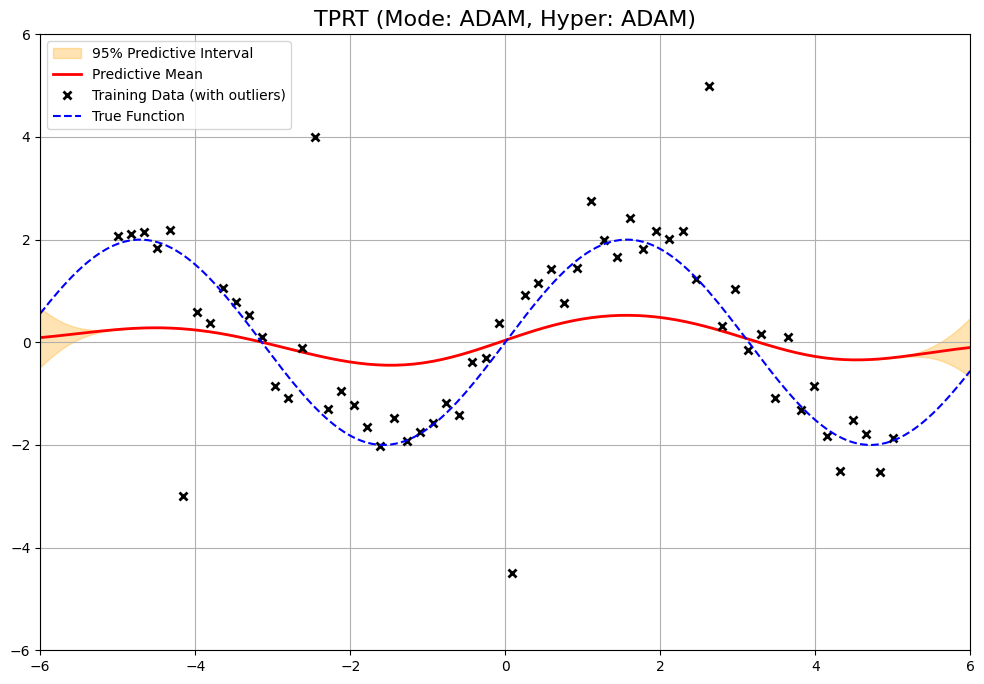

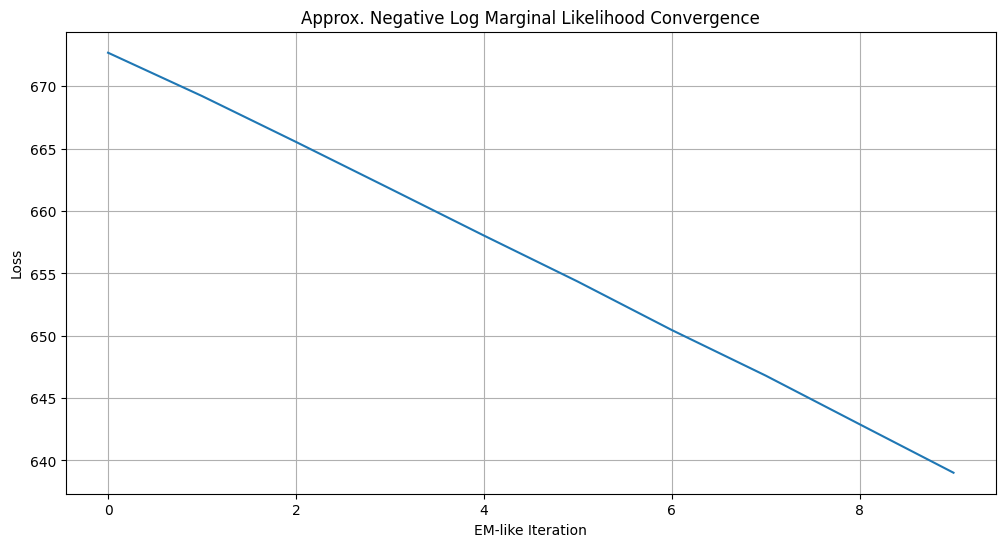

In [19]:
# from .kernels import rbf_kernel
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from scipy.stats import norm
import tqdm
from scipy.optimize import minimize # Scipyのminimizeをインポート

def rbf_kernel(X1, X2, lengthscale=1.0, variance=1.0):
    """
    Computes the RBF kernel matrix between two sets of points.
    """
    lengthscale = torch.as_tensor(lengthscale, dtype=X1.dtype, device=X1.device)
    variance = torch.as_tensor(variance, dtype=X1.dtype, device=X1.device)
    sqdist = torch.cdist(X1, X2, p=2).pow(2)
    return variance * torch.exp(-0.5 * sqdist / lengthscale**2)

# Set default tensor type for better performance with matrix operations
torch.set_default_dtype(torch.float64)


class TPRTFullBatch_Tang:
    """
    Implementation of the full (non-sparse) Student-t Process regression model
    using the Laplace Approximation, based on Tang et al. (2017).

    This extended version allows selecting the optimizer (LBFGS or Adam) for both
    the inner loop (mode-finding) and the outer loop (hyperparameter tuning).
    """
    def __init__(self, X, y, nu_f=2.1, nu_e=2.1,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=1.0,
                 mode_optimizer='cg', hyper_optimizer='adam'):
        """
        Initializes the model.

        Args:
            X (torch.Tensor): Training inputs, shape (N, D).
            y (torch.Tensor): Training outputs, shape (N,).
            nu_f (float): Initial prior degrees of freedom.
            nu_e (float): Initial likelihood degrees of freedom.
            kernel_lengthscale (float): Initial kernel lengthscale.
            kernel_variance (float): Initial kernel variance.
            likelihood_sigma (float): Initial likelihood noise standard deviation.
            mode_optimizer (str): Optimizer for the inner loop ('cg', 'lbfgs' or 'adam').
            hyper_optimizer (str): Optimizer for the outer loop ('lbfgs' or 'adam').
        """
        self.X = X
        self.y = y.view(-1, 1) # Ensure y is always of shape (N, 1)
        self.N, self.D = X.shape

        # --- Hyperparameters as nn.Parameter for optimization ---
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma = nn.Parameter(torch.log(torch.tensor(likelihood_sigma)))
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f)))
        self.log_nu_e = nn.Parameter(torch.log(torch.tensor(nu_e)))
        
        # --- Optimizer Choices ---
        self.mode_optimizer_name = mode_optimizer.lower()
        self.hyper_optimizer_name = hyper_optimizer.lower()
        
        # --- Mode of the posterior f, updated in the E-step ---
        self.m_f = torch.zeros(self.N, 1, dtype=X.dtype, device=X.device)

    def _get_hyperparams(self):
        """Helper to get positive hyperparameters from their log-transformed storage."""
        return {
            "lengthscale": torch.exp(self.log_kernel_lengthscale),
            "variance": torch.exp(self.log_kernel_variance),
            "sigma": torch.exp(self.log_likelihood_sigma),
            "nu_f": torch.exp(self.log_nu_f),
            "nu_e": torch.exp(self.log_nu_e)
        }
        
    def _find_f_hat(self, K_inv, params, max_iter=10, tol=1e-5):
        """
        Inner loop to find the mode f_hat using scipy.optimize.minimize with the CG method.
        This is the core of the E-step.
        """
        # Convert PyTorch tensors to NumPy for SciPy
        # Detach them from the computation graph.
        K_inv_np = K_inv.detach().cpu().numpy()
        y_np = self.y.detach().cpu().numpy()
        params_np = {k: v.detach().cpu().numpy() for k, v in params.items()}
        
        # The objective function (negative log posterior of f) for SciPy
        def objective(f_np):
            f_torch = torch.from_numpy(f_np).view(-1, 1).to(self.X.device)
            
            log_lik_term = ((params_np['nu_e'] + 1) / 2) * np.log(1 + (1 / params_np['nu_e']) * ((y_np - f_np.reshape(-1, 1)) / params_np['sigma'])**2)
            fT_K_inv_f = f_torch.T @ torch.from_numpy(K_inv_np).to(self.X.device) @ f_torch
            log_prior_term = ((params_np['nu_f'] + self.N) / 2) * np.log(1 + (1 / params_np['nu_f']) * fT_K_inv_f)
            
            # Return a scalar numpy float
            return (torch.sum(torch.from_numpy(log_lik_term)) + log_prior_term).cpu().numpy().item()

        # The jacobian (gradient) of the objective function for SciPy
        def jacobian(f_np):
            # Convert numpy array to torch tensor and enable gradient tracking
            f_torch = torch.from_numpy(f_np).view(-1, 1).to(self.X.device).requires_grad_(True)
            
            # We need torch versions of params for gradient calculation
            K_inv_torch = torch.from_numpy(K_inv_np).to(self.X.device)
            y_torch = torch.from_numpy(y_np).to(self.X.device)
            sigma_torch = torch.tensor(params_np['sigma'], device=self.X.device)
            nu_e_torch = torch.tensor(params_np['nu_e'], device=self.X.device)
            nu_f_torch = torch.tensor(params_np['nu_f'], device=self.X.device)

            # Re-calculate loss on torch tensors to build computation graph
            log_lik_term = ((nu_e_torch + 1) / 2) * torch.log(1 + (1 / nu_e_torch) * ((y_torch - f_torch) / sigma_torch).pow(2))
            fT_K_inv_f = f_torch.T @ K_inv_torch @ f_torch
            log_prior_term = ((nu_f_torch + self.N) / 2) * torch.log(1 + (1 / nu_f_torch) * fT_K_inv_f)
            loss = torch.sum(log_lik_term) + log_prior_term
            
            # Compute gradient via autograd
            loss.backward()
            
            # Return gradient as a numpy array
            return f_torch.grad.cpu().numpy().flatten()
            
        # Initial guess from the last known mode
        f_initial_np = self.m_f.detach().cpu().numpy().flatten()
        
        # Use SciPy's CG optimizer
        res = minimize(
            fun=objective,
            x0=f_initial_np,
            method='CG',
            jac=jacobian,
            tol=tol,
            options={'maxiter': max_iter}
        )

        print(f"Mode finding converged: {res.success}, iterations: {res.nit}, final loss: {res.fun:.4f}")
        
        # Convert result back to a PyTorch tensor on the correct device
        return torch.from_numpy(res.x).view(-1, 1).to(self.X.device)

    def _e_step(self, mode_finding_iter=10):
        """
        Performs the E-Step by finding the mode of the posterior p(f|y).
        This method uses detached hyperparameters to avoid building a graph for this optimization.
        """
        # Create a detached copy of the parameters for the E-step.
        # This prevents the inner optimization from affecting the main hyperparameter gradients.
        detached_params = {k: v.detach() for k, v in self._get_hyperparams().items()}

        # Compute K and K_inv using the detached parameters
        K = rbf_kernel(self.X, self.X, detached_params['lengthscale'], detached_params['variance'])
        K += torch.eye(self.N, device=self.X.device) * 1e-6
        L = torch.linalg.cholesky(K)
        K_inv = torch.cholesky_inverse(L)
        
        # Find the mode f_hat. This optimization builds its own local graph for `f`
        # and treats the detached params and K_inv as constants.
        f_hat = self._find_f_hat(K_inv, detached_params, max_iter=mode_finding_iter)
        
        # Update the mode. Use no_grad here to ensure this update is not tracked.
        with torch.no_grad():
            self.m_f.copy_(f_hat)

    def _calculate_neg_log_marginal_likelihood(self):
        """
        Calculates the approximate negative log marginal likelihood, which serves as the loss
        for hyperparameter optimization (M-step).
        """
        params = self._get_hyperparams()
        f_hat = self.m_f # Use the mode found in the E-step

        # 1. Compute Kernel (connected to the graph for hyperparameter gradients)
        K = rbf_kernel(self.X, self.X, params['lengthscale'], params['variance'])
        K += torch.eye(self.N, device=self.X.device) * 1e-6
        L = torch.linalg.cholesky(K)
        K_inv = torch.cholesky_inverse(L)

        # 2. Calculate ln(Q(f_hat)) term
        log_lik_term = ((params['nu_e'] + 1) / 2) * torch.log(1 + (1 / params['nu_e']) * ((self.y - f_hat) / params['sigma']).pow(2))
        fT_K_inv_f = f_hat.T @ K_inv @ f_hat
        log_prior_term = ((params['nu_f'] + self.N) / 2) * torch.log(1 + (1 / params['nu_f']) * fT_K_inv_f)
        ln_Q_at_f_hat = torch.sum(log_lik_term) + log_prior_term

        # 3. Calculate the Hessian A = -∇∇ log p(f|y) |f_hat
        f_hat_flat = f_hat.squeeze()
        prior_hess_num = K_inv * (params['nu_f'] + fT_K_inv_f) - 2 * (K_inv @ torch.outer(f_hat_flat, f_hat_flat) @ K_inv)
        prior_hess_den = (params['nu_f'] + fT_K_inv_f)**2
        prior_hess = (params['nu_f'] + self.N) * (prior_hess_num / prior_hess_den)

        err = self.y - f_hat
        lik_hess_num = err.pow(2) - params['nu_e'] * params['sigma']**2
        lik_hess_den = (err.pow(2) + params['nu_e'] * params['sigma']**2)**2
        W_diag = -(params['nu_e'] + 1) * (lik_hess_num / lik_hess_den)
        W = torch.diag(W_diag.squeeze())
        # Note: A is the *negative* Hessian of the log posterior
        A = -(prior_hess + W)

        # 4. Calculate log determinant term from Laplace approximation
        # The approx. log marginal likelihood is log p(y) ≈ log p(y, f_hat) - 0.5*log|A|
        # The paper's formula (Eq. 18) simplifies to: ln_Q_at_f_hat + 0.5*log|K| - 0.5*log|A| + consts
        log_det_K = 2 * torch.sum(torch.log(torch.diag(L)))
        sign, log_det_A = torch.linalg.slogdet(A)
        if sign.item() <= 0:
            return torch.tensor(float('inf'), device=self.X.device)
        
        log_det_term = 0.5 * log_det_K - 0.5 * log_det_A

        # 5. Calculate constant terms (which depend on hyperparameters)
        c_nu_f_term = torch.lgamma((params['nu_f'] + self.N)/2) - torch.lgamma(params['nu_f']/2) - (self.N/2)*torch.log(math.pi * params['nu_f'])
        c_nu_e_term = self.N * (torch.lgamma((params['nu_e'] + 1)/2) - torch.lgamma(params['nu_e']/2) - 0.5*torch.log(math.pi * params['nu_e']))
        c_sigma_term = -self.N * torch.log(params['sigma'])

        # Total approximate negative log marginal likelihood
        neg_log_marginal_lik = -(ln_Q_at_f_hat + log_det_term + c_nu_f_term + c_nu_e_term + c_sigma_term)
        
        return neg_log_marginal_lik

    def _m_step(self, optimizer):
        """Performs one M-Step update using the chosen optimizer."""
        def closure():
            optimizer.zero_grad()
            loss = self._calculate_neg_log_marginal_likelihood()
            if not (torch.isinf(loss) or torch.isnan(loss)):
                loss.backward()
            else:
                print("Warning: Loss is inf or NaN, skipping gradient calculation.")
            return loss

        if self.hyper_optimizer_name == 'adam':
            loss = closure()
            if not (torch.isinf(loss) or torch.isnan(loss)):
                optimizer.step()
            return loss.item()
        elif self.hyper_optimizer_name == 'lbfgs':
            loss = optimizer.step(closure)
            return loss.item()
        else:
            raise ValueError(f"Unknown hyper optimizer: '{self.hyper_optimizer_name}'. Choose 'lbfgs' or 'adam'.")

    def fit(self, max_iter_global=100, mode_finding_iter=10, lr=0.01):
        """Fits the model using an EM-like algorithm with Laplace Approximation."""
        params_to_optimize = [
            self.log_kernel_lengthscale, self.log_kernel_variance,
            self.log_likelihood_sigma, self.log_nu_f, self.log_nu_e
        ]
        
        if self.hyper_optimizer_name == 'adam':
            optimizer = torch.optim.Adam(params_to_optimize, lr=lr)
        elif self.hyper_optimizer_name == 'lbfgs':
            optimizer = torch.optim.LBFGS(params_to_optimize, lr=0.1, max_iter=10)
        else:
            raise ValueError(f"Unknown hyper optimizer: '{self.hyper_optimizer_name}'. Choose 'lbfgs' or 'adam'.")

        loss_history = []
        print(f"Starting optimization with mode_optimizer='{self.mode_optimizer_name}' and hyper_optimizer='{self.hyper_optimizer_name}'...")
        
        pbar = tqdm.tqdm(range(max_iter_global))
        for i in pbar:
            # E-Step: Find the posterior mode f_hat
            self._e_step(mode_finding_iter=mode_finding_iter)
            
            # M-Step: Update hyperparameters by maximizing the marginal likelihood
            loss = self._m_step(optimizer)
            loss_history.append(loss)
            pbar.set_description(f"Loss: {loss:.4f}")

        print("\nOptimization finished.")
        return loss_history

    def predict(self, X_test):
        """Make predictions at new test points X_test."""
        with torch.no_grad():
            params = self._get_hyperparams()
            f_hat = self.m_f

            K = rbf_kernel(self.X, self.X, params['lengthscale'], params['variance'])
            K += torch.eye(self.N, device=self.X.device) * 1e-6
            L = torch.linalg.cholesky(K)
            K_inv = torch.cholesky_inverse(L)
            
            K_star_x = rbf_kernel(X_test, self.X, params['lengthscale'], params['variance'])
            K_star_star_diag = rbf_kernel(X_test, X_test, params['lengthscale'], params['variance']).diag()

            # Predictive mean
            pred_mean = K_star_x @ K_inv @ f_hat

            # --- Predictive variance (approximated as Gaussian) ---
            f_hat_flat = f_hat.squeeze()
            fT_K_inv_f = f_hat.T @ K_inv @ f_hat
            
            prior_hess_num = K_inv * (params['nu_f'] + fT_K_inv_f) - 2 * (K_inv @ torch.outer(f_hat_flat, f_hat_flat) @ K_inv)
            prior_hess_den = (params['nu_f'] + fT_K_inv_f)**2
            prior_hess = (params['nu_f'] + self.N) * (prior_hess_num / prior_hess_den)
            
            err = self.y - f_hat
            lik_hess_num = err.pow(2) - params['nu_e'] * params['sigma']**2
            lik_hess_den = (err.pow(2) + params['nu_e'] * params['sigma']**2)**2
            W_diag = -(params['nu_e'] + 1) * (lik_hess_num / lik_hess_den)
            W = torch.diag(W_diag.squeeze())
            A = -(prior_hess + W)
            
            try:
                L_A = torch.linalg.cholesky(A)
                # This term is needed for the predictive variance
                v = torch.cholesky_solve(K_inv @ K_star_x.T, L)
                posterior_uncertainty = (v.T @ torch.cholesky_solve(v, L_A)).diag()
            except torch.linalg.LinAlgError:
                print("Warning: Hessian not positive definite during prediction. Variance may be inaccurate.")
                posterior_uncertainty = torch.zeros(X_test.shape[0], device=self.X.device)

            prior_var_reduction = (K_star_x * (K_inv @ K_star_x.T).T).sum(dim=1)
            pred_var = K_star_star_diag - prior_var_reduction + posterior_uncertainty
            pred_var = pred_var.clamp(min=1e-9)
            
            pred_nu = torch.tensor(float('inf'), device=self.X.device)
            
            return pred_mean, pred_var.unsqueeze(1), pred_nu



if __name__ == '__main__':
    # 1. Generate synthetic data with outliers
    N = 60
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    
    torch.manual_seed(42)
    noise = torch.randn(N, 1) * 0.5
    y_train = y_true + noise
    
    outlier_indices = [5, 15, 30, 45, 55]
    y_train[outlier_indices] = torch.tensor([-3.0, 4.0, -4.5, 5.0, -2.5]).unsqueeze(1)

    # 2. Setup and fit the model with chosen optimizers
    # --- Experiment with different optimizers ---
    # Common choice: L-BFGS for mode-finding, Adam for hyperparameters
    # L-BFGS is often better for the inner loop as it's a deterministic subproblem.
    model = TPRTFullBatch_Tang(
        X=X_train,
        y=y_train,
        mode_optimizer='adam',
        hyper_optimizer='adam'
    )
    
    loss_history = model.fit(max_iter_global=10, mode_finding_iter=10000, lr=0.01)

    # 3. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 4. Visualize the results
    plt.figure(figsize=(12, 8))
    
    pred_std = torch.sqrt(pred_var)
    lower_ci = pred_mean - 1.96 * pred_std
    upper_ci = pred_mean + 1.96 * pred_std

    plt.fill_between(X_test.squeeze(), lower_ci.squeeze(), upper_ci.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')
    plt.plot(X_test, torch.sin(X_test) * 2, 'b--', label='True Function')

    plt.title(f"TPRT (Mode: {model.mode_optimizer_name.upper()}, Hyper: {model.hyper_optimizer_name.upper()})", fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # Print final learned hyperparameters
    params = model._get_hyperparams()
    print("\n--- Learned Hyperparameters ---")
    print(f"Kernel Lengthscale: {params['lengthscale'].item():.3f}")
    print(f"Kernel Variance: {params['variance'].item():.3f}")
    print(f"Likelihood Sigma: {params['sigma'].item():.3f}")
    print(f"Prior DoF (nu_f): {params['nu_f'].item():.3f}")
    print(f"Likelihood DoF (nu_e): {params['nu_e'].item():.3f}")

    # Plot loss curve
    plt.figure(figsize=(12, 6))
    plt.plot(loss_history)
    plt.title("Approx. Negative Log Marginal Likelihood Convergence")
    plt.xlabel("EM-like Iteration")
    plt.ylabel("Loss")
    plt.grid(True)
    
    plt.show()

# これをベースに調整するしかない

Starting hyperparameter optimization...


NegLogMargLik: -112.88: 100%|██████████| 100/100 [00:13<00:00,  7.50it/s]



--- Learned Hyperparameters ---
Kernel Lengthscale: 0.826
Kernel Variance: 2.728
Likelihood Sigma: 0.195
Prior DoF (nu_1): 0.774
Likelihood DoF (nu_2): 1.433


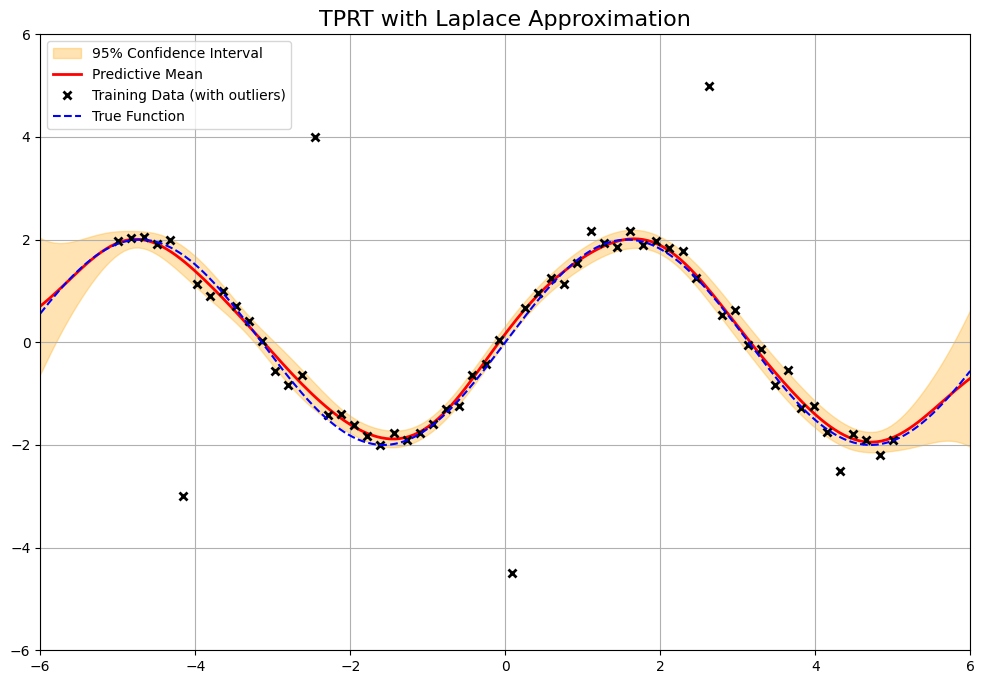

In [20]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
import tqdm

# Set default tensor type for better performance with matrix operations
torch.set_default_dtype(torch.float64)

class TPRT_Laplace(nn.Module):
    """
    Implements Student-t Process Regression with Student-t Likelihood (TPRT)
    using the Laplace Approximation method from Tang et al. (2017).
    """
    def __init__(self, X, y, nu_1=2.1, nu_2=2.1,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        super().__init__()

        self.register_buffer('X', X)
        self.register_buffer('y', y.squeeze())

        self.N, self.D = X.shape

        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma = nn.Parameter(torch.log(torch.tensor(likelihood_sigma)))
        self.log_nu_1 = nn.Parameter(torch.log(torch.tensor(nu_1)))
        self.log_nu_2 = nn.Parameter(torch.log(torch.tensor(nu_2)))

        self.register_buffer('f_hat', torch.zeros(self.N))


    def _get_hyperparams(self):
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        sigma = torch.exp(self.log_likelihood_sigma)
        nu_1 = torch.exp(self.log_nu_1)
        nu_2 = torch.exp(self.log_nu_2)
        return lengthscale, variance, sigma, nu_1, nu_2

    def kernel(self, A, B):
        lengthscale, variance, _, _, _ = self._get_hyperparams()
        sq_dist = torch.cdist(A, B, p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist / lengthscale.pow(2))

    def _calculate_ln_Q(self, f, K_inv, hyperparams):
        _, _, sigma, nu_1, nu_2 = hyperparams
        log_lik_term = ((nu_2 + 1) / 2) * torch.log(1 + (1 / nu_2) * ((self.y - f) / sigma).pow(2))
        fT_K_inv_f = f @ K_inv @ f
        log_prior_term = ((nu_1 + self.N) / 2) * torch.log(1 + (1 / nu_1) * fT_K_inv_f)
        return torch.sum(log_lik_term) + log_prior_term

    def _find_f_hat(self, K_inv_detached, hyperparams_detached, max_iter=10, tol=1e-5):
        """
        Inner loop: Finds f_hat for fixed, DETACHED hyperparameters.
        """
        f = nn.Parameter(self.f_hat.clone())
        optimizer = torch.optim.LBFGS([f], lr=0.5, max_iter=20, line_search_fn="strong_wolfe")

        def closure():
            optimizer.zero_grad()
            loss = self._calculate_ln_Q(f, K_inv_detached, hyperparams_detached)
            loss.backward()
            return loss

        for _ in range(max_iter):
            f_old = f.clone().detach()
            optimizer.step(closure)
            if torch.norm(f.detach() - f_old) < tol:
                break
        
        return f.detach()

    def _calculate_neg_log_marginal_likelihood(self):
        """
        Calculates the loss for hyperparameter optimization.
        """
        hyperparams = self._get_hyperparams()
        _, _, sigma, nu_1, nu_2 = hyperparams

        # 1. Compute Kernel (part of the computation graph)
        K = self.kernel(self.X, self.X) + torch.eye(self.N) * 1e-6
        L = torch.linalg.cholesky(K)
        K_inv = torch.cholesky_inverse(L)

        # 2. Detach inputs for the inner loop and find the mode f_hat
        K_inv_detached = K_inv.detach()
        hyperparams_detached = tuple(p.detach() for p in hyperparams)
        
        # This call now correctly uses detached tensors and will not cause a graph conflict
        f_hat = self._find_f_hat(K_inv_detached, hyperparams_detached)
        self.f_hat.copy_(f_hat) # Update buffer without creating graph connection

        # --- Graph construction for the outer loop starts here ---
        # 3. Calculate ln(Q) at f = f_hat, now connected to the graph via K_inv
        ln_Q_at_f_hat = self._calculate_ln_Q(f_hat, K_inv, hyperparams)

        # 4. Calculate the Negative Hessian A_inv
        f_hat_T_K_inv_f_hat = f_hat @ K_inv @ f_hat
        prior_hess_num = K_inv * (nu_1 + f_hat_T_K_inv_f_hat) - 2 * (K_inv @ torch.outer(f_hat, f_hat) @ K_inv)
        prior_hess_den = (nu_1 + f_hat_T_K_inv_f_hat)**2
        prior_hess = (nu_1 + self.N) * (prior_hess_num / prior_hess_den)

        err = self.y - f_hat
        lik_hess_num = err.pow(2) - nu_2 * sigma**2
        lik_hess_den = (err.pow(2) + nu_2 * sigma**2)**2
        W_diag = -(nu_2 + 1) * (lik_hess_num / lik_hess_den)
        W = torch.diag(W_diag)
        A_inv = prior_hess + W

        # 5. Calculate log|B|
        log_det_K = 2 * torch.sum(torch.log(torch.diag(L)))
        sign, log_det_A_inv = torch.linalg.slogdet(A_inv)
        if sign.item() <= 0:
            return torch.tensor(float('inf'))

        log_det_B = log_det_K + log_det_A_inv

        # 6. Calculate constant terms
        c_nu_1_term = torch.lgamma((nu_1 + self.N)/2) - torch.lgamma(nu_1/2) - (self.N/2)*torch.log(nu_1)
        c_nu_2_term = self.N * (torch.lgamma((nu_2 + 1)/2) - torch.lgamma(nu_2/2) - 0.5*torch.log(nu_2))
        c_sigma_term = -self.N * torch.log(sigma)

        neg_log_marginal_lik = ln_Q_at_f_hat - 0.5 * log_det_B - (c_nu_1_term + c_nu_2_term + c_sigma_term)
        
        return neg_log_marginal_lik

    def fit(self, max_iter=100, lr=0.01):
        print("Starting hyperparameter optimization...")
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        pbar = tqdm.trange(max_iter)

        for i in pbar:
            optimizer.zero_grad()
            loss = self._calculate_neg_log_marginal_likelihood()
            
            if torch.isinf(loss) or torch.isnan(loss):
                print("Warning: Loss is inf or NaN, skipping step.")
                continue

            loss.backward()
            optimizer.step()
            
            pbar.set_description(f"NegLogMargLik: {loss.item():.2f}")

    def predict(self, X_test):
        with torch.no_grad():
            hyperparams = self._get_hyperparams()
            _, _, sigma, nu_1, nu_2 = hyperparams
            f_hat = self.f_hat

            K = self.kernel(self.X, self.X) + torch.eye(self.N) * 1e-6
            L = torch.linalg.cholesky(K)
            K_inv = torch.cholesky_inverse(L)
            K_star_x = self.kernel(X_test, self.X)
            K_star_star_diag = self.kernel(X_test, X_test).diag()

            pred_mean = K_star_x @ K_inv @ f_hat

            f_hat_T_K_inv_f_hat = f_hat @ K_inv @ f_hat
            prior_hess_num = K_inv * (nu_1 + f_hat_T_K_inv_f_hat) - 2 * (K_inv @ torch.outer(f_hat, f_hat) @ K_inv)
            prior_hess_den = (nu_1 + f_hat_T_K_inv_f_hat)**2
            prior_hess = (nu_1 + self.N) * (prior_hess_num / prior_hess_den)
            
            err = self.y - f_hat
            lik_hess_num = err.pow(2) - nu_2 * sigma**2
            lik_hess_den = (err.pow(2) + nu_2 * sigma**2)**2
            W = torch.diag(-(nu_2 + 1) * (lik_hess_num / lik_hess_den))
            A_inv = prior_hess + W
            
            try:
                L_A_inv = torch.linalg.cholesky(A_inv)
                A = torch.cholesky_inverse(L_A_inv)
            except torch.linalg.LinAlgError:
                print("Warning: Hessian not positive definite during prediction. Using pseudo-inverse.")
                A = torch.linalg.pinv(A_inv)

            K_inv_k_star = torch.cholesky_solve(K_star_x.T, L)
            prior_var_reduction = (K_star_x * K_inv_k_star.T).sum(dim=1)
            posterior_uncertainty = (K_star_x @ K_inv @ A @ K_inv @ K_star_x.T).diag()
            pred_var = K_star_star_diag - prior_var_reduction + posterior_uncertainty
            pred_var = pred_var.clamp(min=1e-9)
            
            return pred_mean.unsqueeze(1), pred_var.unsqueeze(1)


if __name__ == '__main__':
    # 1. Generate synthetic data with outliers
    N = 60
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    
    # Add Gaussian noise and some heavy-tailed outlier noise
    torch.manual_seed(42)
    noise = torch.randn(N, 1) * 0.2
    y_train = y_true + noise
    
    # Add significant outliers
    outlier_indices = [5, 15, 30, 45, 55]
    y_train[outlier_indices] = torch.tensor([-3.0, 4.0, -4.5, 5.0, -2.5]).unsqueeze(1)


    # 2. Setup the TPRT_Laplace model
    model = TPRT_Laplace(
        X=X_train,
        y=y_train,
        nu_1=2.1,
        nu_2=2.1,
        kernel_lengthscale=1.0,
        kernel_variance=1.0,
        likelihood_sigma=0.5
    )

    # 3. Fit the model hyperparameters
    model.fit(max_iter=100, lr=0.01)

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var = model.predict(X_test)

    # 5. Visualize the results
    plt.figure(figsize=(12, 8))
    
    pred_std = torch.sqrt(pred_var)
    lower_ci = pred_mean - 1.96 * pred_std
    upper_ci = pred_mean + 1.96 * pred_std

    plt.fill_between(X_test.squeeze(), lower_ci.squeeze(), upper_ci.squeeze(), color='orange', alpha=0.3, label='95% Confidence Interval')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')
    plt.plot(X_test, torch.sin(X_test) * 2, 'b--', label='True Function')

    plt.title('TPRT with Laplace Approximation', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # Print final learned hyperparameters
    l, v, s, n1, n2 = model._get_hyperparams()
    print("\n--- Learned Hyperparameters ---")
    print(f"Kernel Lengthscale: {l.item():.3f}")
    print(f"Kernel Variance: {v.item():.3f}")
    print(f"Likelihood Sigma: {s.item():.3f}")
    print(f"Prior DoF (nu_1): {n1.item():.3f}")
    print(f"Likelihood DoF (nu_2): {n2.item():.3f}")
    
    plt.show()

Starting hyperparameter optimization...


NegLogMargLik: -25.04:   9%|▉         | 9/100 [00:01<00:13,  6.52it/s]

NegLogMargLik: -106.68: 100%|██████████| 100/100 [00:13<00:00,  7.22it/s]



--- Learned Hyperparameters ---
Kernel Lengthscale: 0.779
Kernel Variance: 2.725
Likelihood Sigma: 0.195
Prior DoF (nu_1): 0.802
Likelihood DoF (nu_2): 1.419


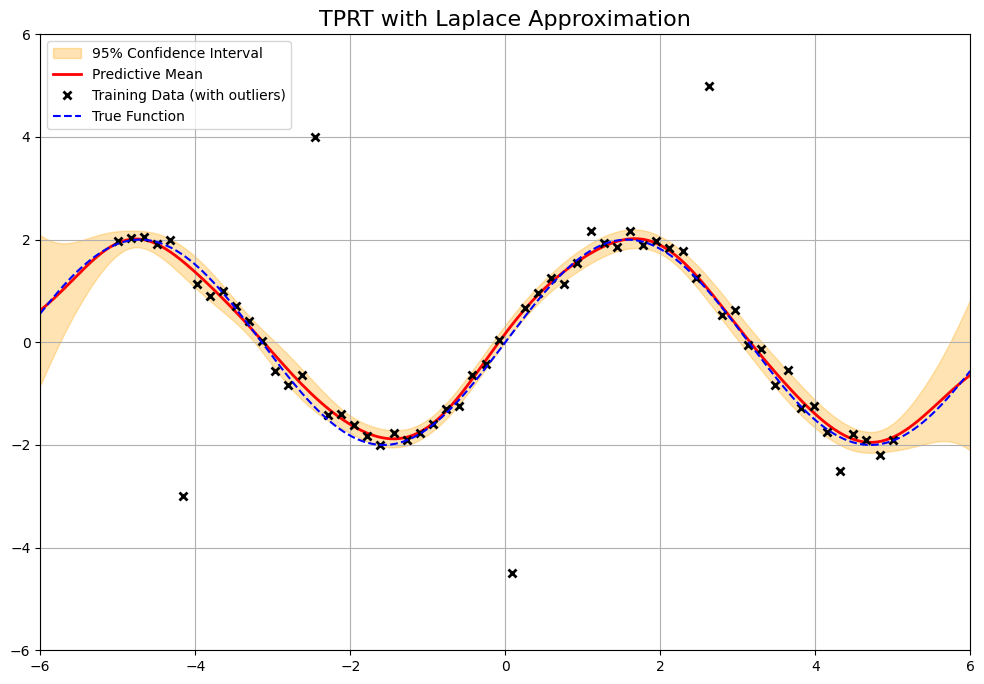

In [6]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
import tqdm

# Set default tensor type for better performance with matrix operations
torch.set_default_dtype(torch.float64)

class TPRT_Laplace(nn.Module):
    """
    Implements Student-t Process Regression with Student-t Likelihood (TPRT)
    using the Laplace Approximation method from Tang et al. (2017).
    """
    def __init__(self, X, y, nu_1=2.1, nu_2=2.1,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        super().__init__()

        self.register_buffer('X', X)
        self.register_buffer('y', y.squeeze())

        self.N, self.D = X.shape

        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma = nn.Parameter(torch.log(torch.tensor(likelihood_sigma)))
        self.log_nu_1 = nn.Parameter(torch.log(torch.tensor(nu_1)))
        self.log_nu_2 = nn.Parameter(torch.log(torch.tensor(nu_2)))

        self.register_buffer('f_hat', torch.zeros(self.N))

        # === ★ 事前分布のインスタンスを定義 ===
        self.lengthscale_prior = GammaPrior(3.0, 6.0)
        self.variance_prior = GammaPrior(2.0, 0.15)
        self.sigma_sq_prior = GammaPrior(1.1, 0.05) 
        self.nu_prior = LogNormalPrior(loc=1.0, scale=1.0)

    def _get_hyperparams(self):
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        sigma = torch.exp(self.log_likelihood_sigma)
        nu_1 = torch.exp(self.log_nu_1)
        nu_2 = torch.exp(self.log_nu_2)
        return lengthscale, variance, sigma, nu_1, nu_2

    def kernel(self, A, B):
        lengthscale, variance, _, _, _ = self._get_hyperparams()
        sq_dist = torch.cdist(A, B, p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist / lengthscale.pow(2))

    def _calculate_ln_Q(self, f, K_inv, hyperparams):
        _, _, sigma, nu_1, nu_2 = hyperparams
        log_lik_term = ((nu_2 + 1) / 2) * torch.log(1 + (1 / nu_2) * ((self.y - f) / sigma).pow(2))
        fT_K_inv_f = f @ K_inv @ f
        log_prior_term = ((nu_1 + self.N) / 2) * torch.log(1 + (1 / nu_1) * fT_K_inv_f)
        return torch.sum(log_lik_term) + log_prior_term

    def _find_f_hat(self, K_inv_detached, hyperparams_detached, max_iter=10, tol=1e-5):
        """
        Inner loop: Finds f_hat for fixed, DETACHED hyperparameters.
        """
        f = nn.Parameter(self.f_hat.clone())
        optimizer = torch.optim.LBFGS([f], lr=0.5, max_iter=20, line_search_fn="strong_wolfe")

        def closure():
            optimizer.zero_grad()
            loss = self._calculate_ln_Q(f, K_inv_detached, hyperparams_detached)
            loss.backward()
            return loss

        for _ in range(max_iter):
            f_old = f.clone().detach()
            optimizer.step(closure)
            if torch.norm(f.detach() - f_old) < tol:
                break
        
        return f.detach()

    # +++ HELPER METHOD FOR HESSIAN CALCULATION +++
    def _calculate_hessian_A_inv(self, f_hat, K_inv, hyperparams):
        """
        Calculates the Negative Hessian A_inv = - (∇∇ln_lik + ∇∇ln_prior)
        This method is now shared between likelihood calculation and prediction.
        """
        _, _, sigma, nu_1, nu_2 = hyperparams

        # Term 1: W = -∇∇ln(likelihood)
        # This is a diagonal matrix.
        err = self.y - f_hat
        err2 = err.pow(2)
        sigma2 = sigma.pow(2)
        W_diag = (nu_2 + 1) * (nu_2 * sigma2 - err2) / (nu_2 * sigma2 + err2).pow(2)
        W = torch.diag(W_diag)

        # Term 2: hess_prior = -∇∇ln(prior)
        fT_K_inv_f = f_hat @ K_inv @ f_hat
        hess_prior_den = (nu_1 + fT_K_inv_f).pow(2)
        K_inv_f = K_inv @ f_hat
        fT_K_inv = K_inv_f.T
        hess_prior_num = (nu_1 + self.N) * (K_inv * (nu_1 + fT_K_inv_f) - 2 * torch.outer(K_inv_f, fT_K_inv))
        hess_prior = hess_prior_num / hess_prior_den
        
        # A_inv = W + hess_prior
        A_inv = W + hess_prior

        # Add jitter for numerical stability
        jitter = torch.eye(self.N, device=self.X.device) * 1e-6
        return A_inv + jitter

    def _calculate_neg_log_marginal_likelihood(self):
        """
        Calculates the loss for hyperparameter optimization.
        """
        hyperparams = self._get_hyperparams()
        
        # 1. Compute Kernel (part of the computation graph)
        K = self.kernel(self.X, self.X) + torch.eye(self.N) * 1e-6
        L = torch.linalg.cholesky(K)
        K_inv = torch.cholesky_inverse(L)

        # 2. Detach inputs for the inner loop and find the mode f_hat
        K_inv_detached = K_inv.detach()
        hyperparams_detached = tuple(p.detach() for p in hyperparams)
        
        f_hat = self._find_f_hat(K_inv_detached, hyperparams_detached)
        self.f_hat.copy_(f_hat)

        # --- Graph construction for the outer loop starts here ---
        # 3. Calculate ln(Q) at f = f_hat, now connected to the graph via K_inv
        ln_Q_at_f_hat = self._calculate_ln_Q(f_hat, K_inv, hyperparams)

        # 4. Calculate the Negative Hessian A_inv using the new helper method
        A_inv = self._calculate_hessian_A_inv(f_hat, K_inv, hyperparams)

        # 5. Calculate log|B|
        log_det_K = 2 * torch.sum(torch.log(torch.diag(L)))
        sign, log_det_A_inv = torch.linalg.slogdet(A_inv)
        if sign.item() <= 0:
            return torch.tensor(float('inf'))

        log_det_B = log_det_K + log_det_A_inv

        # 6. Calculate constant terms
        _, _, sigma, nu_1, nu_2 = hyperparams
        c_nu_1_term = torch.lgamma((nu_1 + self.N)/2) - torch.lgamma(nu_1/2) - (self.N/2)*torch.log(nu_1)
        c_nu_2_term = self.N * (torch.lgamma((nu_2 + 1)/2) - torch.lgamma(nu_2/2) - 0.5*torch.log(nu_2))
        c_sigma_term = -self.N * torch.log(sigma)

        neg_log_marginal_lik = ln_Q_at_f_hat - 0.5 * log_det_B - (c_nu_1_term + c_nu_2_term + c_sigma_term)
        
        return neg_log_marginal_lik

    def _calculate_neg_log_prior_plob(self):
        """
        Calculates the negative log prior probability for hyperparameters.
        This is used to regularize the hyperparameter optimization.
        """
        lengthscale, variance, sigma, nu_1, nu_2 = self._get_hyperparams()

        # Calculate prior probabilities using the defined priors
        log_prior_lengthscale = self.lengthscale_prior.log_prob(lengthscale)
        log_prior_variance = self.variance_prior.log_prob(variance)
        log_prior_sigma = self.sigma_sq_prior.log_prob(sigma.pow(2))
        log_prior_nu_1 = self.nu_prior.log_prob(nu_1)
        log_prior_nu_2 = self.nu_prior.log_prob(nu_2)

        # Sum the log prior probabilities
        neg_log_prior = -(log_prior_lengthscale + log_prior_variance + log_prior_sigma + log_prior_nu_1 + log_prior_nu_2)
        
        return neg_log_prior

    def fit(self, max_iter=100, lr=0.01):
        print("Starting hyperparameter optimization...")
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        pbar = tqdm.trange(max_iter)

        for i in pbar:
            optimizer.zero_grad()
            loss = self._calculate_neg_log_marginal_likelihood() + self._calculate_neg_log_prior_plob()
            
            if torch.isinf(loss) or torch.isnan(loss):
                print(f"Warning: Loss is {loss.item()} at iteration {i}, skipping step.")
                continue

            loss.backward()
            optimizer.step()
            
            pbar.set_description(f"NegLogMargLik: {loss.item():.2f}")

    def predict(self, X_test):
        with torch.no_grad():
            hyperparams = self._get_hyperparams()
            f_hat = self.f_hat

            K = self.kernel(self.X, self.X) + torch.eye(self.N) * 1e-6
            L = torch.linalg.cholesky(K)
            K_inv = torch.cholesky_inverse(L)
            K_star_x = self.kernel(X_test, self.X)
            K_star_star_diag = self.kernel(X_test, X_test).diag()

            pred_mean = K_star_x @ K_inv @ f_hat

            # Use the same helper method to calculate A_inv
            A_inv = self._calculate_hessian_A_inv(f_hat, K_inv, hyperparams)
            
            try:
                # To get A from A_inv, we can do cholesky on A_inv then invert
                L_A_inv = torch.linalg.cholesky(A_inv)
                A = torch.cholesky_inverse(L_A_inv)
            except torch.linalg.LinAlgError:
                print("Warning: Hessian not positive definite during prediction. Using pseudo-inverse.")
                A = torch.linalg.pinv(A_inv)

            # This calculation is for the posterior variance
            # v.T @ K_inv @ A @ K_inv @ v
            # where v = k(x_test, X_train)
            tmp = torch.cholesky_solve(K_star_x.T, L).T # Same as K_star_x @ K_inv
            posterior_uncertainty = (tmp @ A @ tmp.T).diag()

            # The full predictive variance (without noise)
            pred_var = K_star_star_diag - (tmp @ K_star_x.T).diag() + posterior_uncertainty
            pred_var = pred_var.clamp(min=1e-9)
            
            return pred_mean.unsqueeze(1), pred_var.unsqueeze(1)


if __name__ == '__main__':
    # 1. Generate synthetic data with outliers
    N = 60
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    
    # Add Gaussian noise and some heavy-tailed outlier noise
    torch.manual_seed(42)
    noise = torch.randn(N, 1) * 0.2
    y_train = y_true + noise
    
    # Add significant outliers
    outlier_indices = [5, 15, 30, 45, 55]
    y_train[outlier_indices] = torch.tensor([-3.0, 4.0, -4.5, 5.0, -2.5]).unsqueeze(1)


    # 2. Setup the TPRT_Laplace model
    model = TPRT_Laplace(
        X=X_train,
        y=y_train,
        nu_1=2.1,
        nu_2=2.1,
        kernel_lengthscale=1.0,
        kernel_variance=1.0,
        likelihood_sigma=0.5
    )

    # 3. Fit the model hyperparameters
    model.fit(max_iter=100, lr=0.01)

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var = model.predict(X_test)

    # 5. Visualize the results
    plt.figure(figsize=(12, 8))
    
    pred_std = torch.sqrt(pred_var)
    lower_ci = pred_mean - 1.96 * pred_std
    upper_ci = pred_mean + 1.96 * pred_std

    plt.fill_between(X_test.squeeze(), lower_ci.squeeze(), upper_ci.squeeze(), color='orange', alpha=0.3, label='95% Confidence Interval')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')
    plt.plot(X_test, torch.sin(X_test) * 2, 'b--', label='True Function')

    plt.title('TPRT with Laplace Approximation', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # Print final learned hyperparameters
    l, v, s, n1, n2 = model._get_hyperparams()
    print("\n--- Learned Hyperparameters ---")
    print(f"Kernel Lengthscale: {l.item():.3f}")
    print(f"Kernel Variance: {v.item():.3f}")
    print(f"Likelihood Sigma: {s.item():.3f}")
    print(f"Prior DoF (nu_1): {n1.item():.3f}")
    print(f"Likelihood DoF (nu_2): {n2.item():.3f}")
    
    plt.show()

In [9]:
# --- Helper class for Priors ---
class GammaPrior:
    def __init__(self, concentration, rate):
        self.concentration = concentration
        self.rate = rate

    def log_prob(self, x):
        # Log probability density of Gamma distribution (constants omitted)
        return (self.concentration - 1.0) * torch.log(x.clamp(min=1e-9)) - self.rate * x

class LogNormalPrior:
    def __init__(self, loc, scale):
        self.loc = loc
        self.scale = scale
        self.var = scale**2

    def log_prob(self, x):
        # Log probability density of LogNormal distribution (constants omitted)
        log_x = torch.log(x.clamp(min=1e-9))
        return -log_x - (log_x - self.loc)**2 / (2 * self.var)

Starting EM-like optimization...


Loss (Neg. Log Post.): -26.94:  11%|█         | 11/100 [00:01<00:13,  6.49it/s]

Loss (Neg. Log Post.): -106.68: 100%|██████████| 100/100 [00:14<00:00,  7.06it/s]



--- Learned Hyperparameters ---
Kernel Lengthscale: 0.779
Kernel Variance: 2.725
Likelihood Sigma: 0.195
Prior DoF (nu_1): 0.802
Likelihood DoF (nu_2): 1.419


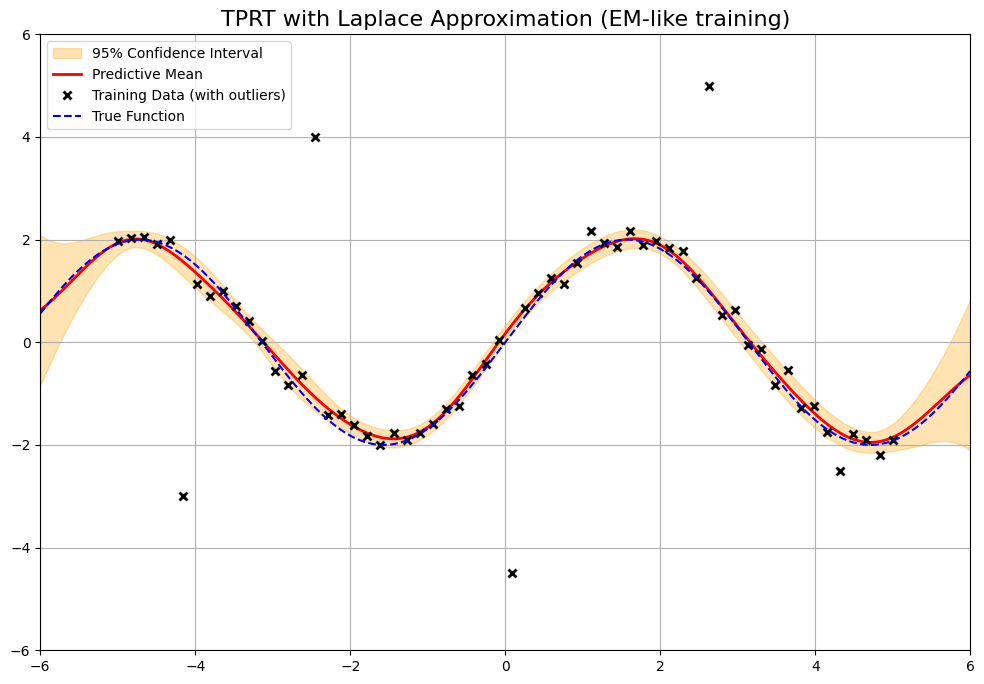

In [ ]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
import tqdm


import torch

def rbf_kernel(X1, X2, lengthscale=1.0, variance=1.0):
    """
    Computes the RBF kernel matrix between two sets of points.
    """
    lengthscale = torch.as_tensor(lengthscale, dtype=X1.dtype, device=X1.device)
    variance = torch.as_tensor(variance, dtype=X1.dtype, device=X1.device)
    sqdist = torch.cdist(X1, X2, p=2).pow(2)
    return variance * torch.exp(-0.5 * sqdist / lengthscale**2)


torch.set_default_dtype(torch.float64)

class TPRTFullBatch_Tang(nn.Module):
    def __init__(self, X, y, kernel=rbf_kernel, nu_1=2.1, nu_2=2.1,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        super().__init__()

        self.register_buffer('X', X)
        self.register_buffer('y', y.squeeze())
        self.N, self.D = X.shape

        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma = nn.Parameter(torch.log(torch.tensor(likelihood_sigma)))
        self.log_nu_1 = nn.Parameter(torch.log(torch.tensor(nu_1)))
        self.log_nu_2 = nn.Parameter(torch.log(torch.tensor(nu_2)))

        self.register_buffer('f_hat', torch.zeros(self.N))

        self.lengthscale_prior = GammaPrior(3.0, 6.0)
        self.variance_prior = GammaPrior(2.0, 0.15)
        self.sigma_sq_prior = GammaPrior(1.1, 0.05) 
        self.nu_prior = LogNormalPrior(loc=1.0, scale=1.0)

        self.kernel = kernel

    def _get_hyperparams(self):
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        sigma = torch.exp(self.log_likelihood_sigma)
        nu_1 = torch.exp(self.log_nu_1)
        nu_2 = torch.exp(self.log_nu_2)
        # ★ 戻り値をタプルに変更して一貫性を保つ
        return lengthscale, variance, sigma, nu_1, nu_2

    def _calculate_ln_Q(self, f, K_inv, hyperparams):
        # hyperparams はタプルとして受け取る
        _, _, sigma, nu_1, nu_2 = hyperparams
        log_lik_term = ((nu_2 + 1) / 2) * torch.log(1 + (1 / nu_2) * ((self.y - f) / sigma).pow(2))
        fT_K_inv_f = f @ K_inv @ f
        log_prior_term = ((nu_1 + self.N) / 2) * torch.log(1 + (1 / nu_1) * fT_K_inv_f)
        return torch.sum(log_lik_term) + log_prior_term

    def _find_f_hat(self, K_inv_detached, hyperparams_detached, max_iter=10, tol=1e-5):
        # hyperparams_detached はタプル
        f = nn.Parameter(self.f_hat.clone())
        optimizer = torch.optim.LBFGS([f], lr=0.5, max_iter=20, line_search_fn="strong_wolfe")
        def closure():
            optimizer.zero_grad()
            loss = self._calculate_ln_Q(f, K_inv_detached, hyperparams_detached)
            loss.backward()
            return loss
        for _ in range(max_iter):
            f_old = f.clone().detach()
            optimizer.step(closure)
            if torch.norm(f.detach() - f_old) < tol: break
        return f.detach()

    def _calculate_hessian_A_inv(self, f_hat, K_inv, hyperparams):
        # hyperparams はタプルとして受け取る
        _, _, sigma, nu_1, nu_2 = hyperparams
        err = self.y - f_hat
        err2 = err.pow(2)
        sigma2 = sigma.pow(2)
        W_diag = (nu_2 + 1) * (nu_2 * sigma2 - err2) / (nu_2 * sigma2 + err2).pow(2)
        W = torch.diag(W_diag)
        fT_K_inv_f = f_hat @ K_inv @ f_hat
        hess_prior_den = (nu_1 + fT_K_inv_f).pow(2)
        K_inv_f = K_inv @ f_hat
        fT_K_inv = K_inv_f.T
        hess_prior_num = (nu_1 + self.N) * (K_inv * (nu_1 + fT_K_inv_f) - 2 * torch.outer(K_inv_f, fT_K_inv))
        hess_prior = hess_prior_num / hess_prior_den
        A_inv = W + hess_prior
        jitter = torch.eye(self.N, device=self.X.device) * 1e-6
        return A_inv + jitter

    def _calculate_neg_log_marginal_likelihood(self):
        hyperparams = self._get_hyperparams() # タプルが返る
        f_hat = self.f_hat
        
        K = self.kernel(self.X, self.X) + torch.eye(self.N) * 1e-6
        try: L = torch.linalg.cholesky(K)
        except torch.linalg.LinAlgError: return torch.tensor(float('inf'))
        K_inv = torch.cholesky_inverse(L)

        ln_Q_at_f_hat = self._calculate_ln_Q(f_hat, K_inv, hyperparams)
        A_inv = self._calculate_hessian_A_inv(f_hat, K_inv, hyperparams)

        log_det_K = 2 * torch.sum(torch.log(torch.diag(L)))
        sign, log_det_A_inv = torch.linalg.slogdet(A_inv)
        if sign.item() <= 0: return torch.tensor(float('inf'))

        log_det_B = log_det_K + log_det_A_inv

        _, _, sigma, nu_1, nu_2 = hyperparams
        c_nu_1_term = torch.lgamma((nu_1 + self.N)/2) - torch.lgamma(nu_1/2) - (self.N/2)*torch.log(nu_1)
        c_nu_2_term = self.N * (torch.lgamma((nu_2 + 1)/2) - torch.lgamma(nu_2/2) - 0.5*torch.log(nu_2))
        c_sigma_term = -self.N * torch.log(sigma)

        neg_log_marginal_lik = ln_Q_at_f_hat - 0.5 * log_det_B - (c_nu_1_term + c_nu_2_term + c_sigma_term)
        return neg_log_marginal_lik

    def _calculate_neg_log_prior_plob(self):
        lengthscale, variance, sigma, nu_1, nu_2 = self._get_hyperparams()
        log_prior_lengthscale = self.lengthscale_prior.log_prob(lengthscale)
        log_prior_variance = self.variance_prior.log_prob(variance)
        log_prior_sigma = self.sigma_sq_prior.log_prob(sigma.pow(2))
        log_prior_nu_1 = self.nu_prior.log_prob(nu_1)
        log_prior_nu_2 = self.nu_prior.log_prob(nu_2)
        neg_log_prior = -(log_prior_lengthscale.sum() + log_prior_variance + log_prior_sigma + log_prior_nu_1 + log_prior_nu_2)
        return neg_log_prior
    
    def _e_step(self, mode_finding_iter=10):
        with torch.no_grad():
            hyperparams_detached = self._get_hyperparams()
            K_detached = self.kernel(self.X, self.X) + torch.eye(self.N) * 1e-6
            L_detached = torch.linalg.cholesky(K_detached)
            K_inv_detached = torch.cholesky_inverse(L_detached)
        
        f_hat = self._find_f_hat(K_inv_detached, hyperparams_detached, max_iter=mode_finding_iter)
        self.f_hat.copy_(f_hat)

    def _m_step(self, optimizer):
        optimizer.zero_grad()
        loss = self._calculate_neg_log_marginal_likelihood() + self._calculate_neg_log_prior_plob()
        if torch.isinf(loss) or torch.isnan(loss):
            print(f"Warning: Loss is {loss.item()} during M-step, skipping update.")
            return loss.item()
        loss.backward()
        optimizer.step()
        return loss.item()

    def fit(self, max_iter=100, mode_finding_iter=10, lr=0.01):
        print("Starting EM-like optimization...")
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        pbar = tqdm.trange(max_iter)
        for i in pbar:
            self._e_step(mode_finding_iter=mode_finding_iter)
            loss = self._m_step(optimizer)
            pbar.set_description(f"Loss (Neg. Log Post.): {loss:.2f}")

    def predict(self, X_test):
        with torch.no_grad():
            hyperparams = self._get_hyperparams()
            f_hat = self.f_hat
            K = self.kernel(self.X, self.X) + torch.eye(self.N) * 1e-6
            L = torch.linalg.cholesky(K)
            K_inv = torch.cholesky_inverse(L)
            K_star_x = self.kernel(X_test, self.X)
            K_star_star_diag = self.kernel(X_test, X_test).diag()
            pred_mean = K_star_x @ K_inv @ f_hat
            A_inv = self._calculate_hessian_A_inv(f_hat, K_inv, hyperparams)
            try:
                L_A_inv = torch.linalg.cholesky(A_inv)
                A = torch.cholesky_inverse(L_A_inv)
            except torch.linalg.LinAlgError:
                print("Warning: Hessian not positive definite during prediction. Using pseudo-inverse.")
                A = torch.linalg.pinv(A_inv)
            tmp = torch.cholesky_solve(K_star_x.T, L).T
            posterior_uncertainty = (tmp @ A @ tmp.T).diag()
            pred_var = K_star_star_diag - (tmp @ K_star_x.T).diag() + posterior_uncertainty
            pred_var = pred_var.clamp(min=1e-9)
            return pred_mean.unsqueeze(1), pred_var.unsqueeze(1)

if __name__ == '__main__':
    N = 60
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    
    torch.manual_seed(42)
    noise = torch.randn(N, 1) * 0.2
    y_train = y_true + noise
    
    outlier_indices = [5, 15, 30, 45, 55]
    y_train[outlier_indices] = torch.tensor([-3.0, 4.0, -4.5, 5.0, -2.5]).unsqueeze(1)

    model = TPRT_Laplace(X=X_train, y=y_train, nu_1=2.1, nu_2=2.1,
                         kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.5)
    
    model.fit(max_iter=100, mode_finding_iter=10, lr=0.01)

    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var = model.predict(X_test)

    plt.figure(figsize=(12, 8))
    pred_std = torch.sqrt(pred_var)
    lower_ci = pred_mean - 1.96 * pred_std
    upper_ci = pred_mean + 1.96 * pred_std

    plt.fill_between(X_test.squeeze(), lower_ci.squeeze(), upper_ci.squeeze(), color='orange', alpha=0.3, label='95% Confidence Interval')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')
    plt.plot(X_test, torch.sin(X_test) * 2, 'b--', label='True Function')
    plt.title('TPRT with Laplace Approximation (EM-like training)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    l, v, s, n1, n2 = model._get_hyperparams()
    print("\n--- Learned Hyperparameters ---")
    print(f"Kernel Lengthscale: {l.item():.3f}")
    print(f"Kernel Variance: {v.item():.3f}")
    print(f"Likelihood Sigma: {s.item():.3f}")
    print(f"Prior DoF (nu_1): {n1.item():.3f}")
    print(f"Likelihood DoF (nu_2): {n2.item():.3f}")
    
    plt.show()

In [2]:
import torch

# --- Helper class for Priors ---
class GammaPrior:
    def __init__(self, concentration, rate):
        self.concentration = concentration
        self.rate = rate

    def log_prob(self, x):
        # Log probability density of Gamma distribution (constants omitted)
        return (self.concentration - 1.0) * torch.log(x.clamp(min=1e-9)) - self.rate * x

class LogNormalPrior:
    def __init__(self, loc, scale):
        self.loc = loc
        self.scale = scale
        self.var = scale**2

    def log_prob(self, x):
        # Log probability density of LogNormal distribution (constants omitted)
        log_x = torch.log(x.clamp(min=1e-9))
        return -log_x - (log_x - self.loc)**2 / (2 * self.var)

In [3]:
def rbf_kernel(X1, X2, lengthscale, variance):
    """
    Computes the RBF kernel matrix between two sets of points.
    """
    sqdist = torch.cdist(X1 / lengthscale, X2 / lengthscale, p=2).pow(2)
    return variance * torch.exp(-0.5 * sqdist)

Starting EM-like optimization...


  0%|          | 0/1000 [00:00<?, ?it/s]/tmp/ipykernel_647489/9540916.py:92: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4413.)
  fT_K_inv = K_inv_f.T
Loss (Neg. Log Post.): -342.43: 100%|██████████| 1000/1000 [02:10<00:00,  7.66it/s]



--- Learned Hyperparameters ---
Kernel Lengthscale: 0.479
Kernel Variance: 367.096
Likelihood Sigma: 0.133
Prior DoF (nu_1): 0.008
Likelihood DoF (nu_2): 1.746


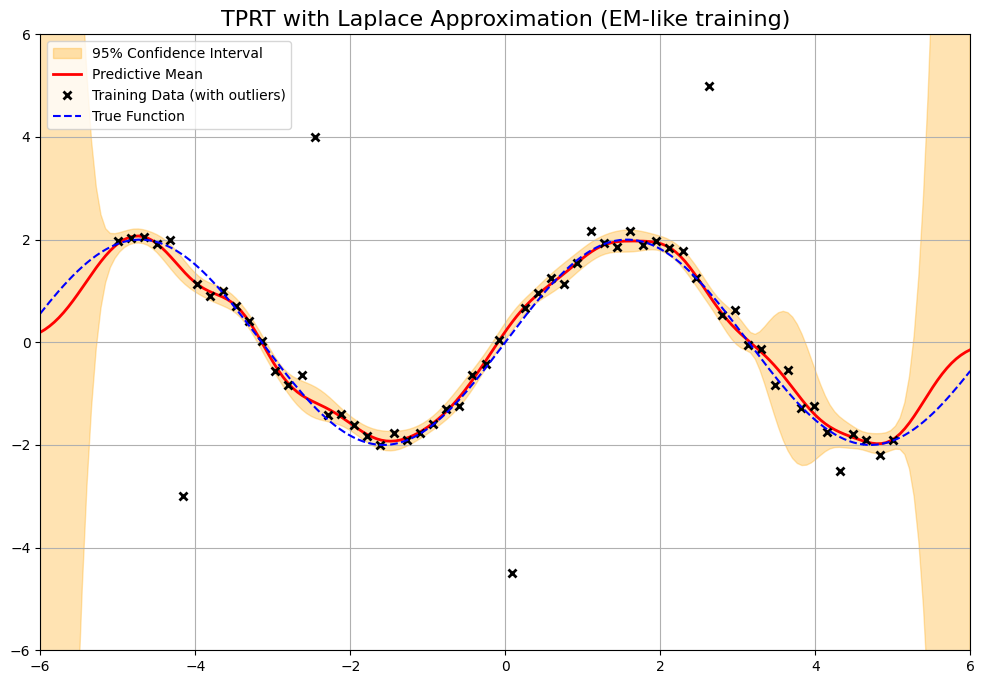

In [4]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
import tqdm



# +++ 1. カーネル関数をクラス外に定義 +++
def rbf_kernel(X1, X2, lengthscale, variance):
    """
    Computes the RBF kernel matrix between two sets of points.
    """
    sqdist = torch.cdist(X1 / lengthscale, X2 / lengthscale, p=2).pow(2)
    return variance * torch.exp(-0.5 * sqdist)

# 他のカーネルの例
def matern52_kernel(X1, X2, lengthscale, variance):
    sqdist = torch.cdist(X1 / lengthscale, X2 / lengthscale, p=2)
    term1 = 1 + math.sqrt(5) * sqdist + (5/3) * sqdist**2
    term2 = torch.exp(-math.sqrt(5) * sqdist)
    return variance * term1 * term2


torch.set_default_dtype(torch.float64)

class TPRT_Laplace(nn.Module):
    # +++ 2. __init__ を修正 +++
    def __init__(self, X, y, kernel=rbf_kernel, nu_1=2.1, nu_2=2.1,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        super().__init__()

        self.register_buffer('X', X)
        self.register_buffer('y', y.squeeze())
        self.N, self.D = X.shape
        
        # カーネル関数をインスタンス変数として保持
        self.kernel = kernel

        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma = nn.Parameter(torch.log(torch.tensor(likelihood_sigma)))
        self.log_nu_1 = nn.Parameter(torch.log(torch.tensor(nu_1)))
        self.log_nu_2 = nn.Parameter(torch.log(torch.tensor(nu_2)))

        self.register_buffer('f_hat', torch.zeros(self.N))

        self.lengthscale_prior = GammaPrior(3.0, 6.0)
        self.variance_prior = GammaPrior(2.0, 0.15)
        self.sigma_sq_prior = GammaPrior(1.1, 0.05) 
        self.nu_prior = LogNormalPrior(loc=1.0, scale=1.0)

    def _get_hyperparams(self):
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        sigma = torch.exp(self.log_likelihood_sigma)
        nu_1 = torch.exp(self.log_nu_1)
        nu_2 = torch.exp(self.log_nu_2)
        return lengthscale, variance, sigma, nu_1, nu_2

    def _calculate_ln_Q(self, f, K_inv, hyperparams):
        _, _, sigma, nu_1, nu_2 = hyperparams
        log_lik_term = ((nu_2 + 1) / 2) * torch.log(1 + (1 / nu_2) * ((self.y - f) / sigma).pow(2))
        fT_K_inv_f = f @ K_inv @ f
        log_prior_term = ((nu_1 + self.N) / 2) * torch.log(1 + (1 / nu_1) * fT_K_inv_f)
        return torch.sum(log_lik_term) + log_prior_term

    def _find_f_hat(self, K_inv_detached, hyperparams_detached, max_iter=10, tol=1e-5):
        f = nn.Parameter(self.f_hat.clone())
        optimizer = torch.optim.LBFGS([f], lr=0.5, max_iter=20, line_search_fn="strong_wolfe")
        def closure():
            optimizer.zero_grad()
            loss = self._calculate_ln_Q(f, K_inv_detached, hyperparams_detached)
            loss.backward()
            return loss
        for _ in range(max_iter):
            f_old = f.clone().detach()
            optimizer.step(closure)
            if torch.norm(f.detach() - f_old) < tol: break
        return f.detach()

    def _calculate_hessian_A_inv(self, f_hat, K_inv, hyperparams):
        _, _, sigma, nu_1, nu_2 = hyperparams
        err = self.y - f_hat
        err2 = err.pow(2)
        sigma2 = sigma.pow(2)
        W_diag = (nu_2 + 1) * (nu_2 * sigma2 - err2) / (nu_2 * sigma2 + err2).pow(2)
        W = torch.diag(W_diag)
        fT_K_inv_f = f_hat @ K_inv @ f_hat
        hess_prior_den = (nu_1 + fT_K_inv_f).pow(2)
        K_inv_f = K_inv @ f_hat
        fT_K_inv = K_inv_f.T
        hess_prior_num = (nu_1 + self.N) * (K_inv * (nu_1 + fT_K_inv_f) - 2 * torch.outer(K_inv_f, fT_K_inv))
        hess_prior = hess_prior_num / hess_prior_den
        A_inv = W + hess_prior
        jitter = torch.eye(self.N, device=self.X.device) * 1e-6
        return A_inv + jitter

    def _calculate_neg_log_marginal_likelihood(self):
        hyperparams = self._get_hyperparams()
        f_hat = self.f_hat
        lengthscale, variance, sigma, nu_1, nu_2 = hyperparams
        
        # +++ 3. self.kernel をハイパラ付きで呼び出し +++
        K = self.kernel(self.X, self.X, lengthscale, variance) + torch.eye(self.N) * 1e-6
        try: L = torch.linalg.cholesky(K)
        except torch.linalg.LinAlgError: return torch.tensor(float('inf'))
        K_inv = torch.cholesky_inverse(L)

        ln_Q_at_f_hat = self._calculate_ln_Q(f_hat, K_inv, hyperparams)
        A_inv = self._calculate_hessian_A_inv(f_hat, K_inv, hyperparams)

        log_det_K = 2 * torch.sum(torch.log(torch.diag(L)))
        sign, log_det_A_inv = torch.linalg.slogdet(A_inv)
        if sign.item() <= 0: return torch.tensor(float('inf'))

        log_det_B = log_det_K + log_det_A_inv

        c_nu_1_term = torch.lgamma((nu_1 + self.N)/2) - torch.lgamma(nu_1/2) - (self.N/2)*torch.log(nu_1)
        c_nu_2_term = self.N * (torch.lgamma((nu_2 + 1)/2) - torch.lgamma(nu_2/2) - 0.5*torch.log(nu_2))
        c_sigma_term = -self.N * torch.log(sigma)

        neg_log_marginal_lik = ln_Q_at_f_hat - 0.5 * log_det_B - (c_nu_1_term + c_nu_2_term + c_sigma_term)
        return neg_log_marginal_lik

    def _calculate_neg_log_prior_plob(self):
        lengthscale, variance, sigma, nu_1, nu_2 = self._get_hyperparams()
        log_prior_lengthscale = self.lengthscale_prior.log_prob(lengthscale)
        log_prior_variance = self.variance_prior.log_prob(variance)
        log_prior_sigma = self.sigma_sq_prior.log_prob(sigma.pow(2))
        log_prior_nu_1 = self.nu_prior.log_prob(nu_1)
        log_prior_nu_2 = self.nu_prior.log_prob(nu_2)
        neg_log_prior = -(log_prior_lengthscale.sum() + log_prior_variance + log_prior_sigma + log_prior_nu_1 + log_prior_nu_2)
        return neg_log_prior
    
    def _e_step(self, mode_finding_iter=10):
        with torch.no_grad():
            hyperparams_detached = self._get_hyperparams()
            lengthscale_d, variance_d, _, _, _ = hyperparams_detached
            K_detached = self.kernel(self.X, self.X, lengthscale_d, variance_d) + torch.eye(self.N) * 1e-6
            L_detached = torch.linalg.cholesky(K_detached)
            K_inv_detached = torch.cholesky_inverse(L_detached)
        
        f_hat = self._find_f_hat(K_inv_detached, hyperparams_detached, max_iter=mode_finding_iter)
        self.f_hat.copy_(f_hat)

    def _m_step(self, optimizer):
        optimizer.zero_grad()
        loss = self._calculate_neg_log_marginal_likelihood() + self._calculate_neg_log_prior_plob()
        if torch.isinf(loss) or torch.isnan(loss):
            print(f"Warning: Loss is {loss.item()} during M-step, skipping update.")
            return loss.item()
        loss.backward()
        optimizer.step()
        return loss.item()

    def fit(self, max_iter=100, mode_finding_iter=10, lr=0.01):
        print("Starting EM-like optimization...")
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        pbar = tqdm.trange(max_iter)
        for i in pbar:
            self._e_step(mode_finding_iter=mode_finding_iter)
            loss = self._m_step(optimizer)
            pbar.set_description(f"Loss (Neg. Log Post.): {loss:.2f}")

    def predict(self, X_test):
        with torch.no_grad():
            hyperparams = self._get_hyperparams()
            lengthscale, variance, _, _, _ = hyperparams
            f_hat = self.f_hat
            
            K = self.kernel(self.X, self.X, lengthscale, variance) + torch.eye(self.N) * 1e-6
            L = torch.linalg.cholesky(K)
            K_inv = torch.cholesky_inverse(L)
            K_star_x = self.kernel(X_test, self.X, lengthscale, variance)
            K_star_star_diag = self.kernel(X_test, X_test, lengthscale, variance).diag()

            pred_mean = K_star_x @ K_inv @ f_hat
            A_inv = self._calculate_hessian_A_inv(f_hat, K_inv, hyperparams)
            try:
                L_A_inv = torch.linalg.cholesky(A_inv)
                A = torch.cholesky_inverse(L_A_inv)
            except torch.linalg.LinAlgError:
                print("Warning: Hessian not positive definite during prediction. Using pseudo-inverse.")
                A = torch.linalg.pinv(A_inv)
            tmp = torch.cholesky_solve(K_star_x.T, L).T
            posterior_uncertainty = (tmp @ A @ tmp.T).diag()
            pred_var = K_star_star_diag - (tmp @ K_star_x.T).diag() + posterior_uncertainty
            pred_var = pred_var.clamp(min=1e-9)
            return pred_mean.unsqueeze(1), pred_var.unsqueeze(1)

if __name__ == '__main__':
    N = 60
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    
    torch.manual_seed(42)
    noise = torch.randn(N, 1) * 0.2
    y_train = y_true + noise
    
    outlier_indices = [5, 15, 30, 45, 55]
    y_train[outlier_indices] = torch.tensor([-3.0, 4.0, -4.5, 5.0, -2.5]).unsqueeze(1)

    # モデルのインスタンス化時にカーネル関数を渡す
    model = TPRT_Laplace(X=X_train, y=y_train, kernel=rbf_kernel, nu_1=2.1, nu_2=2.1,
                         kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.5)
    
    model.fit(max_iter=1000, mode_finding_iter=10, lr=0.01)

    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var = model.predict(X_test)

    plt.figure(figsize=(12, 8))
    pred_std = torch.sqrt(pred_var)
    lower_ci = pred_mean - 1.96 * pred_std
    upper_ci = pred_mean + 1.96 * pred_std

    plt.fill_between(X_test.squeeze(), lower_ci.squeeze(), upper_ci.squeeze(), color='orange', alpha=0.3, label='95% Confidence Interval')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')
    plt.plot(X_test, torch.sin(X_test) * 2, 'b--', label='True Function')
    plt.title('TPRT with Laplace Approximation (EM-like training)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    l, v, s, n1, n2 = model._get_hyperparams()
    print("\n--- Learned Hyperparameters ---")
    print(f"Kernel Lengthscale: {l.item():.3f}")
    print(f"Kernel Variance: {v.item():.3f}")
    print(f"Likelihood Sigma: {s.item():.3f}")
    print(f"Prior DoF (nu_1): {n1.item():.3f}")
    print(f"Likelihood DoF (nu_2): {n2.item():.3f}")
    
    plt.show()